# Demo: Rotation-Equivariant Component Analysis for 4D-STEM

This notebook is a **code-level companion** to the manuscript section **“Rotation-Equivariant Component Analysis”**.
It starts from **denoised diffraction patterns** (the self-supervised denoising step is described in the manuscript) and demonstrates the downstream steps used to generate **spatially resolved orientation maps**.

All intermediate arrays are kept in **4D scan form** `(Nx, Ny, ..., ...)`.


# <span style="color: blue; ">Data analysis procedure (aligned with the manuscript)</span>

This demo follows the workflow described around Fig. 1a and the corresponding Methods/Results text:

1. **High-frequency Component Extraction (High-pass Filtering)**  
2. **Data Transformation based on Fourier Transformation**  
   - Polar coordinate transform  
   - 1D Fourier transform along the angular axis  
3. **Crystal Component Analysis (NMF)** using **MALSpy** to obtain `C` and `S`  
4. **Crystal Orientation Estimation**  
   - Robust peak detection (radial → rotational order)  
   - Phase-based in-plane angle estimation per component  
5. **Mapping back to the scan grid** using `C` as a spatial mask (output is already `(Nx, Ny, ...)`)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from CCA import highpass_filter, polar_transform, fourier_transform, orientation_map

from malspy import NMF

## Load input dataset

The input is a **4D ndarray** with shape `(Nx, Ny, H, W)`, where:
- `(Nx, Ny)` is the probe-position scan grid (real space),
- `(H, W)` is the diffraction image size (reciprocal space).

In the manuscript, this corresponds to **denoised diffraction patterns** used as input for the rotation-equivariant analysis.


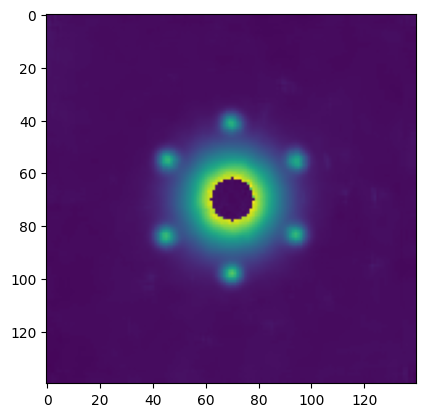

In [2]:
dataset = np.load("data/denoised_sample.npy")
plt.imshow(dataset[0,0])
# Expected shape: (Nx, Ny, H, W)
# Example: dataset.shape -> (100, 100, 140, 140)


## 1) High-frequency Component Extraction (High-pass Filtering)

As described in the Methods (**High-frequency Component Extraction**), a Tukey window is applied to suppress edge discontinuities,
then an FFT-domain **Gaussian high-pass filter** removes low-frequency background while preserving diffraction spots.

Output is kept in 4D scan form `(Nx, Ny, H, W)`.


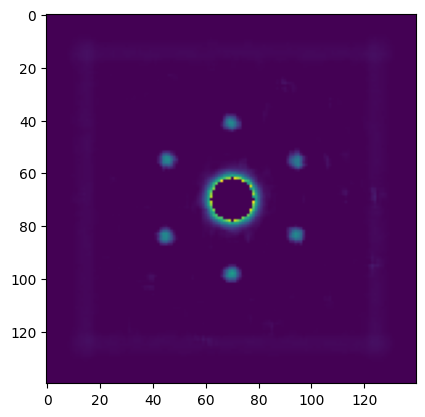

In [3]:
highpass_images = highpass_filter(dataset)
plt.imshow(highpass_images[0,0])
# Output shape: (Nx, Ny, H, W)


## 1.5) Logarithmic scaling
In the analysis of the experimental data in this paper, the data was converted to a log scale, and the following analysis was performed.

Output is kept in 4D scan form `(Nx, Ny, H, W)`.

In [4]:
# Disabled for this demo: the synthetic sample data does not need log
# compression. Uncomment to reproduce the log-scale preprocessing used for
# the real experimental data in the manuscript, then continue the pipeline
# below with `log_images` in place of `highpass_images`.

# threshold = 10
# highpass_images[highpass_images < threshold] = threshold
# log_images = np.log(highpass_images) - np.log(10)

## 2) Data Transformation: Polar Coordinates

Each diffraction image is transformed from Cartesian reciprocal-space coordinates to **polar coordinates** `(r, θ)` to enable angular analysis.
A fixed in-plane rotation may be applied prior to the transform (matching the implementation used for the manuscript figures).


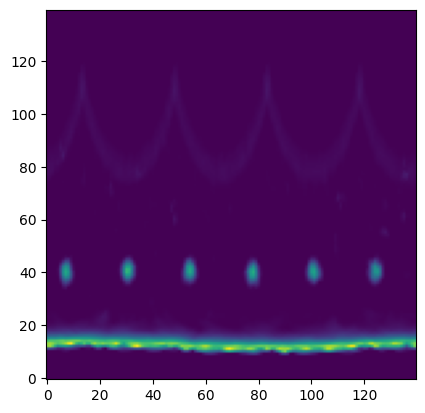

In [5]:
polar_images = polar_transform(highpass_images)
plt.imshow(polar_images[0,0].T, origin="lower")
# Output shape: (Nx, Ny, R, T) where (R,T) matches the chosen output_shape in warp_polar


## 3) Data Transformation: Fourier Transform along the Angular Axis

A **1D Fourier transform** is applied along the **angular axis** for each radius `r`, producing a representation in the `(r, m)` domain
where `m` is the rotational order.

- The **magnitude** is (approximately) **rotation-invariant** and is used for component analysis.
- The **phase** encodes **in-plane orientation** and is used for orientation estimation.


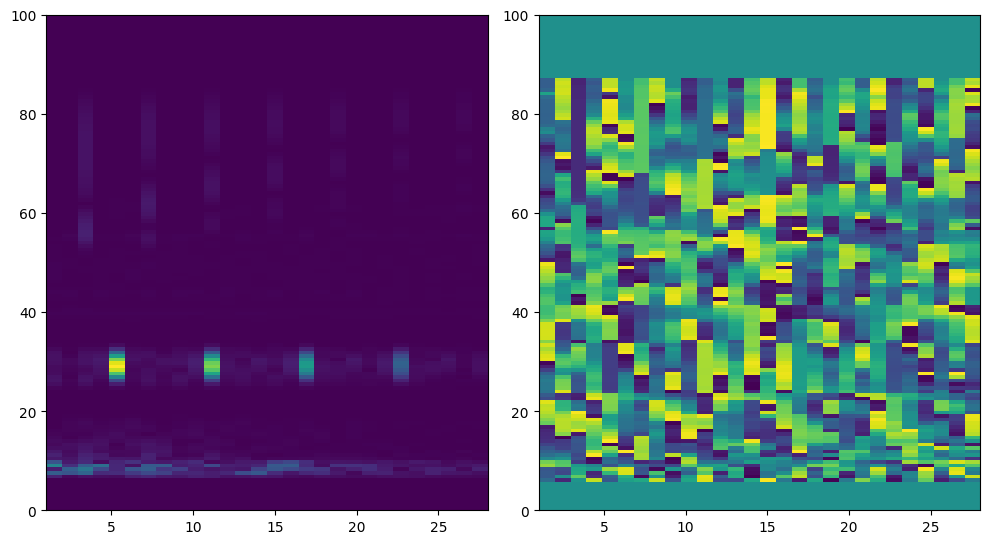

In [6]:
fft_images = fourier_transform(polar_images)
plt.figure(figsize=(10,16))
plt.subplot(3,2,1)
plt.imshow(np.abs(fft_images[0,0,:,2:30]), 
           origin="lower",aspect="auto", extent=[1, np.abs(fft_images[0,:,2:30]).shape[1], 0, np.abs(fft_images[0,:,2:30]).shape[0]])
plt.subplot(3,2,2)
plt.imshow(np.angle(fft_images[0,0,:,2:30]), 
           origin="lower",aspect="auto", extent=[1, np.angle(fft_images[0,:,2:30]).shape[1], 0, np.angle(fft_images[0,:,2:30]).shape[0]])
plt.tight_layout()
# Output shape: (Nx, Ny, R, K) complex


## 4) Crystal Component Analysis (NMF with MALSpy)

Following the manuscript (**Crystal Component Analysis**), NMF is applied to the **Fourier magnitudes**:

- Stack per-scan features into a data matrix `X` (each scan position is one row).
- Factorize `X ≈ W H` under nonnegativity constraints.
- In this project, NMF is computed using **MALSpy** (HALS-based optimization in the manuscript).

We reshape the NMF outputs into:
- `C` (spatial coefficients): `(Nx, Ny, n_components)`  ← derived from `W`
- `S` (component bases): `(R, K, n_components)`        ← derived from `H`

These `C` and `S` are then used for peak detection and orientation estimation.


Training NMF model....
1th iteration of NMF algorithm
# updates: 49
2th iteration of NMF algorithm
# updates: 49
3th iteration of NMF algorithm
# updates: 49


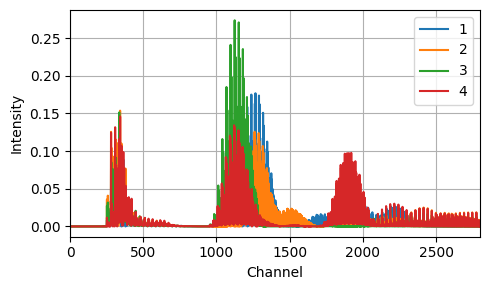

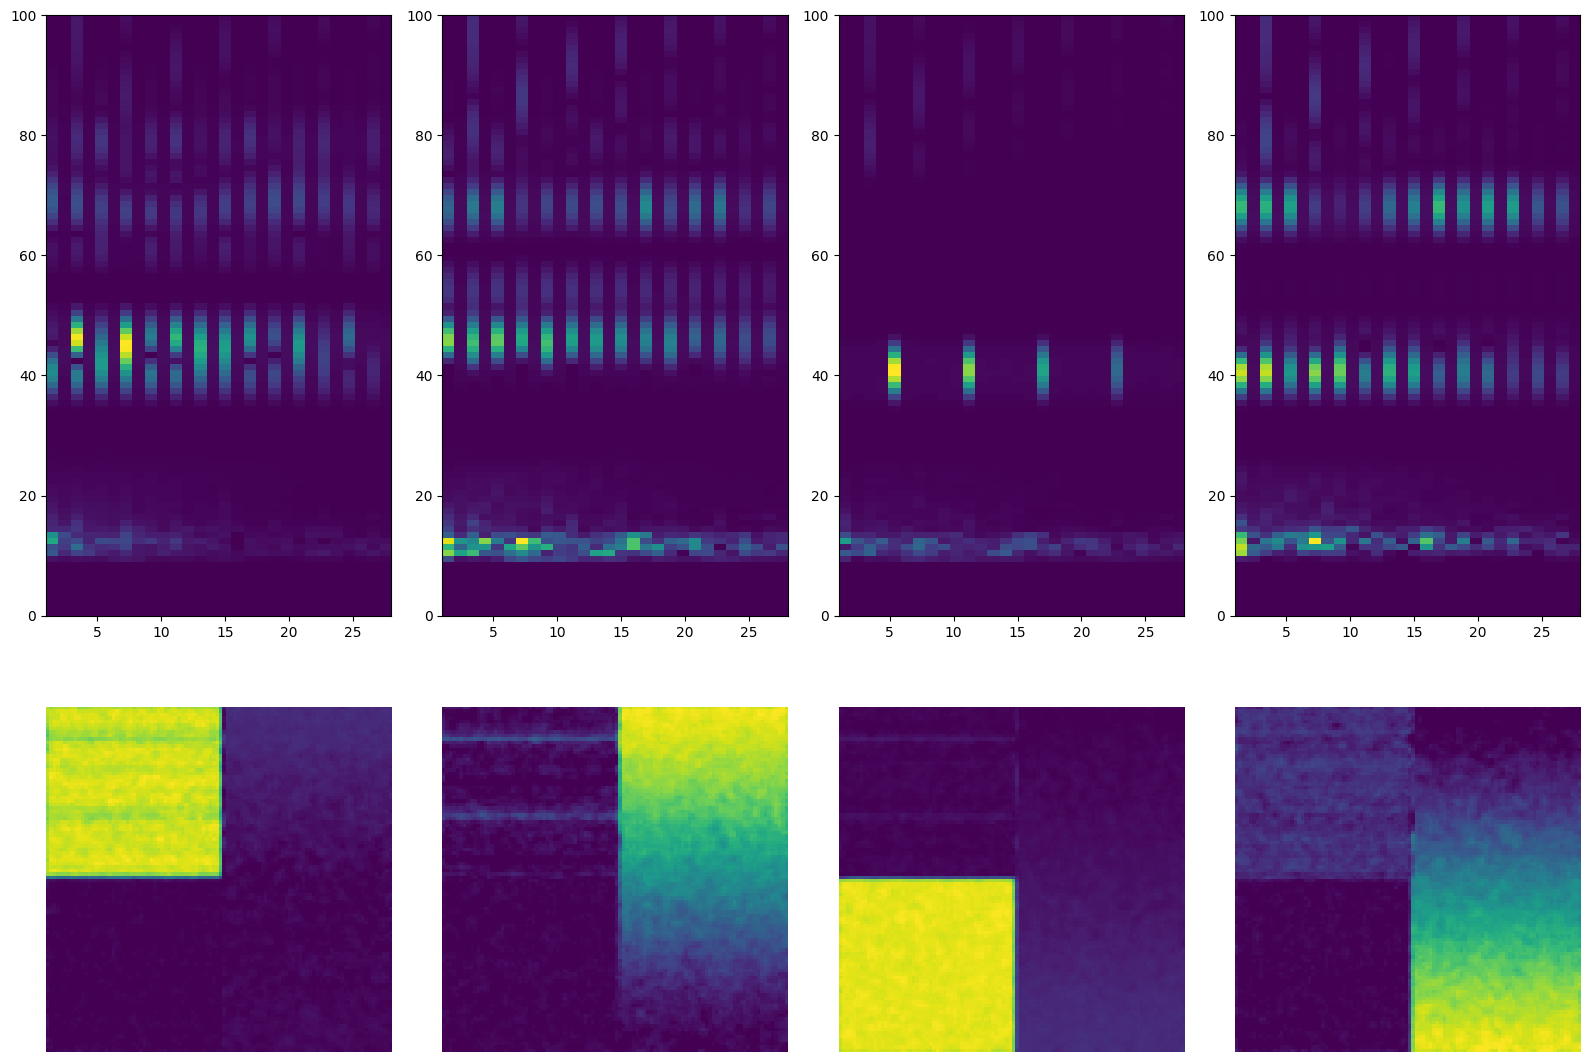

In [7]:
fft_abs = np.abs(fft_images[:,:,:100,2:30])
X = fft_abs.reshape(fft_abs.shape[0]*fft_abs.shape[1],fft_abs.shape[2]*fft_abs.shape[3])
n_components = 4
model_nmf = NMF(n_components=n_components, reps=3, max_itr=50)
model_nmf.fit(X)
model_nmf.plot_spectra(figsize=(5,3), normalize=True)
C = model_nmf.C_.reshape(fft_abs.shape[0],fft_abs.shape[1],n_components)
S = model_nmf.S_.reshape(fft_abs.shape[2],fft_abs.shape[3],n_components)
plt.figure(figsize=(16,12))
for i in range(n_components):
    plt.subplot(2,n_components,i+1)
    plt.imshow(S[:,:,i], origin="lower", aspect="auto", extent=[1, S[:,:,0].shape[1], 0, S[:,:,0].shape[0]])
    plt.subplot(2,n_components,n_components+i+1)
    plt.imshow(C[:,:,i], origin="lower")
    plt.axis("off")
plt.tight_layout()
# Provide segmentation and component spectra from your NMF step.
# C: (Nx, Ny, n_components) soft assignment / coefficients per scan pixel
# S: (R, K, n_components) component spectra in the Fourier-magnitude domain
# n_components: number of components
#
# Example (pseudo-code):
# C = ...
# S = ...
# n_components = C.shape[-1]


## 5) Crystal Orientation Estimation and Mapping (per component)

This section corresponds to **Crystal Orientation Estimation** in the manuscript.

For each NMF component:
1. **Radial peak detection** using a robust z-score on the radial profile (to select active radial bands).
2. **Rotational-order selection** using a robust z-score on the rotational-order profile (even orders are considered).
   The first significant peak is used as the **fundamental rotational order** `f0` (fallback: `f0=2` if no peak is detected).
3. **Phase-based orientation estimation** from the Fourier phase at `(r, f0)`, converted to an in-plane angle by dividing by `f0`.
4. **Spatial masking** using `C` (component membership) so that orientations are assigned only within the corresponding structural region.

The output is a list of masked 2D maps per component (sorted by a score).


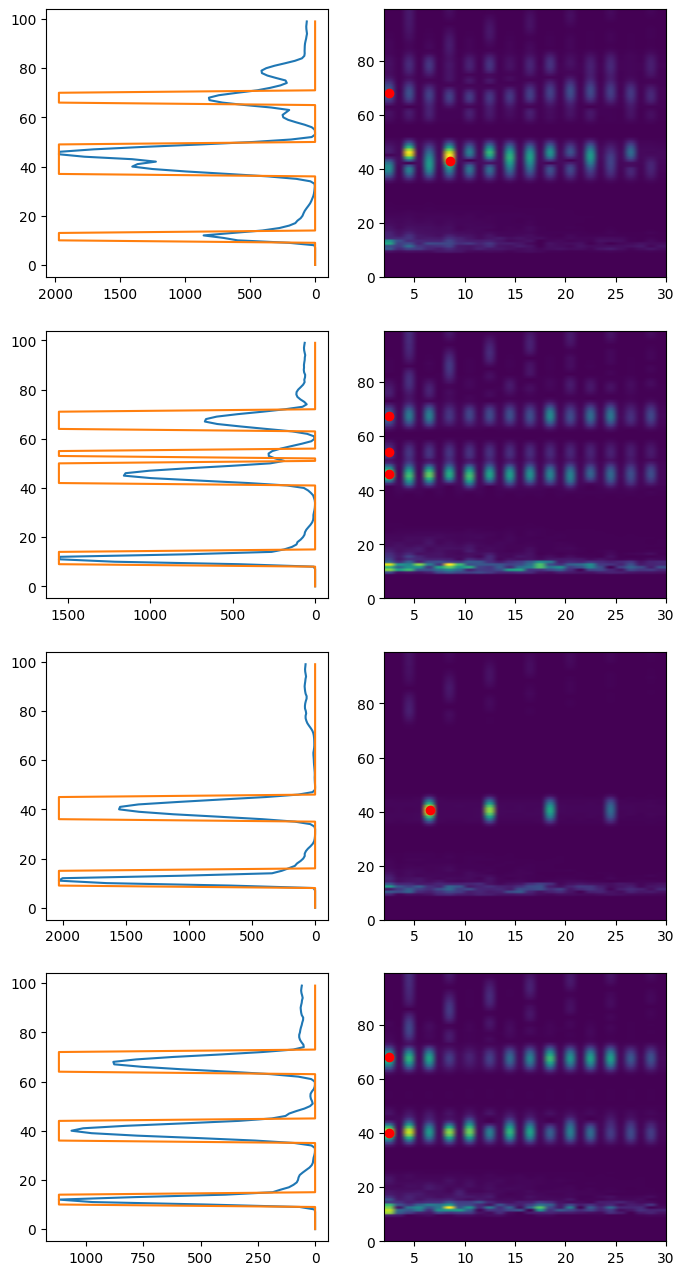

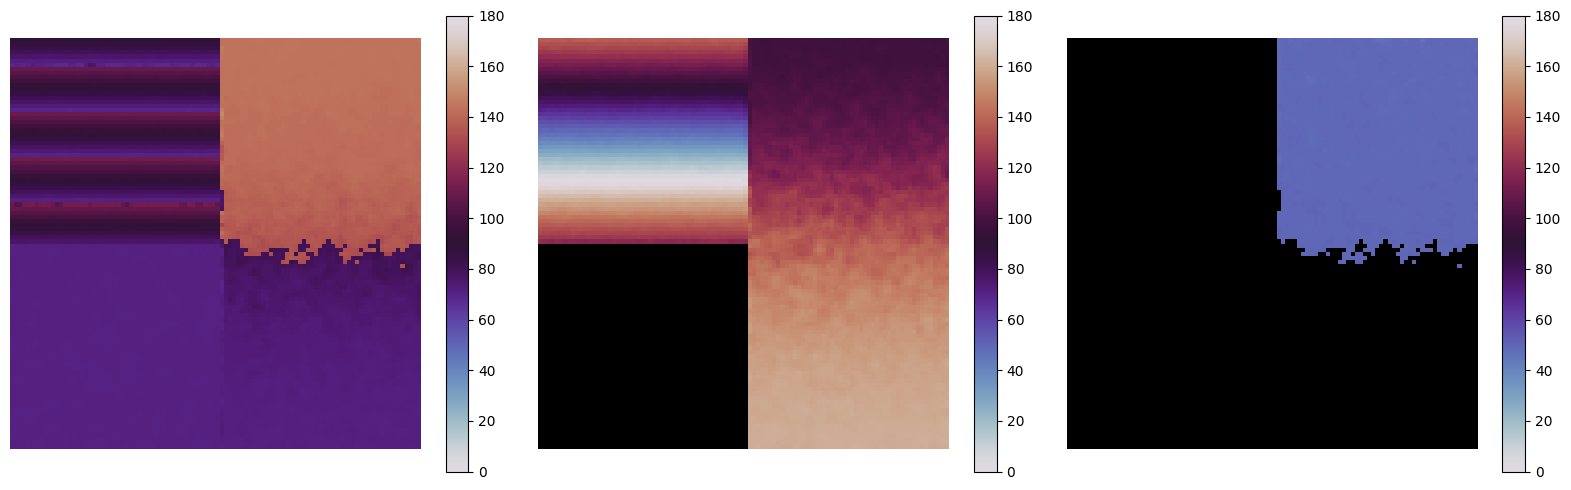

In [ ]:
peak_positions, angle_maps = orientation_map(fft_images[:,:,:100,2:30], C, S, k_r = 2, k_f = 1.5)
black = np.zeros_like(C[:,:,0])
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.imshow(black, cmap="gray", vmin=0, vmax=100000)
for i in range(n_components):
    plt.imshow(angle_maps[i][0], cmap="hsv", origin="lower",vmin=0,vmax=180)
plt.axis("off")
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(black, cmap="gray", vmin=0, vmax=100000)
for i in range(n_components):
    if len(angle_maps[i]) > 1:
        plt.imshow(angle_maps[i][1], cmap="hsv", origin="lower",vmin=0,vmax=180)
plt.axis("off")
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(black, cmap="gray", vmin=0, vmax=100000)
for i in range(n_components):
    if len(angle_maps[i]) > 2:
        plt.imshow(angle_maps[i][2], cmap="hsv", origin="lower",vmin=0,vmax=180)
plt.axis("off")
plt.colorbar()
plt.tight_layout()
# angle_maps is a nested list: angle_maps[component_index][candidate_index] -> masked (Nx, Ny) map


In [9]:
# End of demo.